In [13]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import tensorflow as tf

from tensorflow.keras import Model, Input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryFocalCrossentropy
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    Add,
    Concatenate,
    Multiply,
    GaussianNoise,
    Activation
)
from sklearn.metrics import (
    precision_recall_curve,
    f1_score
)


from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss
)

from tensorflow.keras.regularizers import l2
import warnings  
warnings.filterwarnings('ignore') 
from sklearn.preprocessing import StandardScaler, MinMaxScaler  
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV,cross_validate  #  
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix  
import shap

In [2]:
TARGET = "HadHeartAttack"
train_df = pd.read_csv("train_scaled_smote.csv")
validation_df = pd.read_csv("validation_scaled.csv")
test_df = pd.read_csv("test_scaled.csv")

print("=" * 70)
print("DATASETS LOADED SUCCESSFULLY")
print("=" * 70)

print("Training Shape   :", train_df.shape)
print("Validation Shape :", validation_df.shape)
print("Test Shape       :", test_df.shape)


X_train = train_df.drop(columns=[TARGET]).copy()
y_train = train_df[TARGET].copy()

X_val = validation_df.drop(columns=[TARGET]).copy()
y_val = validation_df[TARGET].copy()

X_test = test_df.drop(columns=[TARGET]).copy()
y_test = test_df[TARGET].copy()


def encode_target(y):

    y = pd.Series(y).copy()

    # Already numeric
    if pd.api.types.is_numeric_dtype(y):
        return y.astype(np.int32)

    # Convert string labels
    y = (
        y.astype(str)
         .str.strip()
         .str.upper()
    )

    y = y.replace({
        "NO": 0,
        "YES": 1
    })


    y = pd.to_numeric(y, errors="raise")

    return y.astype(np.int32)


y_train = encode_target(y_train)
y_val = encode_target(y_val)
y_test = encode_target(y_test)

X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

INPUT_DIM = X_train.shape[1]
print("\nUnique Labels")
print("-" * 40)

print("Train :", np.unique(y_train))
print("Val   :", np.unique(y_val))
print("Test  :", np.unique(y_test))

assert set(np.unique(y_train)).issubset({0, 1})
assert set(np.unique(y_val)).issubset({0, 1})
assert set(np.unique(y_test)).issubset({0, 1})
print("\nMissing Values")
print("-" * 40)

print("Train :", X_train.isnull().sum().sum())
print("Val   :", X_val.isnull().sum().sum())
print("Test  :", X_test.isnull().sum().sum())



print("\nTraining Distribution")
print("-" * 40)
print(y_train.value_counts())

print("\nValidation Distribution")
print("-" * 40)
print(y_val.value_counts())

print("\nTest Distribution")
print("-" * 40)
print(y_test.value_counts())
print("\nNumber of Features :", INPUT_DIM)

print("\nFirst 10 Features")
print("-" * 40)
print(list(X_train.columns[:10]))

print("\n" + "=" * 70)
print("DATA SUMMARY")
print("=" * 70)

print(f"Training Samples   : {len(X_train):,}")
print(f"Validation Samples : {len(X_val):,}")
print(f"Test Samples       : {len(X_test):,}")

print(f"\nInput Features     : {INPUT_DIM}")

print("\nTarget Variable :", TARGET)

print("\n✓ Target labels verified")
print("✓ Features converted to float32")
print("✓ Training data loaded")
print("✓ Validation data loaded")
print("✓ Test data loaded")

print("=" * 70)
print("CELL 1 COMPLETED SUCCESSFULLY")
print("=" * 70)

DATASETS LOADED SUCCESSFULLY
Training Shape   : (622452, 32)
Validation Shape : (41243, 32)
Test Shape       : (41243, 32)

Unique Labels
----------------------------------------
Train : [0 1]
Val   : [0 1]
Test  : [0 1]

Missing Values
----------------------------------------
Train : 0
Val   : 0
Test  : 0

Training Distribution
----------------------------------------
HadHeartAttack
0    311226
1    311226
Name: count, dtype: int64

Validation Distribution
----------------------------------------
HadHeartAttack
0    38903
1     2340
Name: count, dtype: int64

Test Distribution
----------------------------------------
HadHeartAttack
0    38903
1     2340
Name: count, dtype: int64

Number of Features : 31

First 10 Features
----------------------------------------
['Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivity', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadOtherCancer']

DATA SUMMARY
Training Samples   : 622,452
Validation Sampl

In [3]:


L2 = 5e-5

DROPOUT1 = 0.30
DROPOUT2 = 0.25
DROPOUT3 = 0.20
DROPOUT4 = 0.15


def dense_block(x, units, dropout):

    x = Dense(
        units,
        kernel_initializer="he_normal",
        kernel_regularizer=l2(L2),
        use_bias=False
    )(x)

    x = BatchNormalization()(x)

    x = Activation("gelu")(x)

    x = Dropout(dropout)(x)

    return x


def residual_block(x, units, dropout):

    shortcut = x

    if x.shape[-1] != units:

        shortcut = Dense(
            units,
            kernel_initializer="he_normal",
            kernel_regularizer=l2(L2),
            use_bias=False
        )(shortcut)

        shortcut = BatchNormalization()(shortcut)

    y = Dense(
        units,
        kernel_initializer="he_normal",
        kernel_regularizer=l2(L2),
        use_bias=False
    )(x)

    y = BatchNormalization()(y)

    y = Activation("gelu")(y)

    y = Dense(
        units,
        kernel_initializer="he_normal",
        kernel_regularizer=l2(L2),
        use_bias=False
    )(y)

    y = BatchNormalization()(y)

    x = Add()([shortcut, y])

    x = Activation("gelu")(x)

    x = Dropout(dropout)(x)

    return x

def build_fnn(input_dim):

    inputs = Input(shape=(input_dim,))

    x = GaussianNoise(0.02)(inputs)

    x = dense_block(x, 256, DROPOUT1)

    x = dense_block(x, 128, DROPOUT2)

    x = dense_block(x, 64, DROPOUT3)

    x = dense_block(x, 32, DROPOUT4)

    outputs = Dense(
        1,
        activation="sigmoid"
    )(x)

    return Model(
        inputs,
        outputs,
        name="FNN"
    )

def build_wide_deep(input_dim):

    inputs = Input(shape=(input_dim,))

    # Wide branch

    wide = Dense(
        32,
        activation="linear"
    )(inputs)

    # Deep branch

    deep = dense_block(
        inputs,
        256,
        DROPOUT1
    )

    deep = dense_block(
        deep,
        128,
        DROPOUT2
    )

    deep = dense_block(
        deep,
        64,
        DROPOUT3
    )

    merged = Concatenate()([
        wide,
        deep
    ])

    merged = dense_block(
        merged,
        64,
        DROPOUT4
    )

    outputs = Dense(
        1,
        activation="sigmoid"
    )(merged)

    return Model(
        inputs,
        outputs,
        name="Wide_Deep"
    )

def build_residual(input_dim):

    inputs = Input(shape=(input_dim,))

    x = dense_block(
        inputs,
        256,
        DROPOUT1
    )

    x = residual_block(
        x,
        256,
        0.25
    )

    x = residual_block(
        x,
        128,
        0.20
    )

    x = residual_block(
        x,
        64,
        0.15
    )

    x = dense_block(
        x,
        32,
        0.10
    )

    outputs = Dense(
        1,
        activation="sigmoid"
    )(x)

    return Model(
        inputs,
        outputs,
        name="Residual"
    )


def build_attention(input_dim):

    inputs = Input(shape=(input_dim,))

    attention = Dense(
        input_dim,
        activation="sigmoid"
    )(inputs)

    attended = Multiply()([
        inputs,
        attention
    ])

    x = dense_block(
        attended,
        256,
        DROPOUT1
    )

    x = dense_block(
        x,
        128,
        DROPOUT2
    )

    x = dense_block(
        x,
        64,
        DROPOUT3
    )

    x = dense_block(
        x,
        32,
        DROPOUT4
    )

    outputs = Dense(
        1,
        activation="sigmoid"
    )(x)

    return Model(
        inputs,
        outputs,
        name="Attention"
    )


model_builders = {

    "FNN": build_fnn,

    "Wide_Deep": build_wide_deep,

    "Residual": build_residual,

    "Attention": build_attention

}

print("=" * 70)
print("DEEP LEARNING MODELS READY")
print("=" * 70)

for model_name in model_builders:
    print("✓", model_name)

print("\nTotal Models:", len(model_builders))

print("\nInput Features:", INPUT_DIM)

print("=" * 70)
print("CELL 2 COMPLETED SUCCESSFULLY")
print("=" * 70)

DEEP LEARNING MODELS READY
✓ FNN
✓ Wide_Deep
✓ Residual
✓ Attention

Total Models: 4

Input Features: 31
CELL 2 COMPLETED SUCCESSFULLY


In [4]:


BATCH_SIZE = 512

EPOCHS = 100

LEARNING_RATE = 3e-4

loss_function = tf.keras.losses.BinaryFocalCrossentropy(

    gamma=2.0,

    alpha=0.50,

    label_smoothing=0.01,

    apply_class_balancing=False

)

metrics = [

    tf.keras.metrics.AUC(
        curve="PR",
        name="pr_auc"
    ),

    tf.keras.metrics.AUC(
        curve="ROC",
        name="roc_auc"
    ),

    tf.keras.metrics.BinaryAccuracy(
        name="accuracy"
    ),

    tf.keras.metrics.Precision(
        name="precision"
    ),

    tf.keras.metrics.Recall(
        name="recall"
    )
]


def create_optimizer():

    return Adam(

        learning_rate=LEARNING_RATE,

        clipnorm=1.0

    )



def compile_model(model):

    model.compile(

        optimizer=create_optimizer(),

        loss=loss_function,

        metrics=metrics

    )

    return model



def create_callbacks(model_name):

    return [

        EarlyStopping(

            monitor="val_pr_auc",

            mode="max",

            patience=50,

            restore_best_weights=True,

            verbose=1

        ),

        ReduceLROnPlateau(

            monitor="val_pr_auc",

            mode="max",

            factor=0.5,

            patience=50,

            min_lr=1e-6,

            verbose=1

        ),

        ModelCheckpoint(

            filepath=f"{model_name}_best.keras",

            monitor="val_pr_auc",

            mode="max",

            save_best_only=True,

            verbose=1

        )

    ]


def train_model(model_name):

    print("=" * 70)
    print(f"Training {model_name}")
    print("=" * 70)

    model = model_builders[model_name](INPUT_DIM)

    model = compile_model(model)

    history = model.fit(

        X_train,

        y_train,

        validation_data=(

            X_val,

            y_val

        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        shuffle=True,

        verbose=2,

        callbacks=create_callbacks(model_name)

    )

    return model, history



MODEL_NAMES = [

    "FNN",

    "Wide_Deep",

    "Residual",

    "Attention"

]

print("\nTraining Settings")
print("-" * 40)

print("Loss          : Binary Focal Loss")
print("Gamma         : 2.0")
print("Alpha         : 0.50")
print("Learning Rate :", LEARNING_RATE)
print("Batch Size    :", BATCH_SIZE)
print("Epochs        :", EPOCHS)
print("Monitor       : Validation PR-AUC")
print("Gradient Clip : Yes")



Training Settings
----------------------------------------
Loss          : Binary Focal Loss
Gamma         : 2.0
Alpha         : 0.50
Learning Rate : 0.0003
Batch Size    : 512
Epochs        : 100
Monitor       : Validation PR-AUC
Gradient Clip : Yes


In [5]:
trained_models = {}
histories = {}

for model_name in MODEL_NAMES:

    model, history = train_model(model_name)

    trained_models[model_name] = model

    histories[model_name] = history

print("\n" + "="*70)
print("ALL MODELS TRAINED")
print("="*70)

print("\nModels Available:")

for name in trained_models:
    print("✓", name)

Training FNN
Epoch 1/100

Epoch 1: val_pr_auc improved from -inf to 0.22946, saving model to FNN_best.keras
1216/1216 - 18s - 15ms/step - accuracy: 0.7345 - loss: 0.1882 - pr_auc: 0.7697 - precision: 0.7161 - recall: 0.7770 - roc_auc: 0.8036 - val_accuracy: 0.6929 - val_loss: 0.1784 - val_pr_auc: 0.2295 - val_precision: 0.1362 - val_recall: 0.8261 - val_roc_auc: 0.8331 - learning_rate: 3.0000e-04
Epoch 2/100

Epoch 2: val_pr_auc improved from 0.22946 to 0.23154, saving model to FNN_best.keras
1216/1216 - 14s - 12ms/step - accuracy: 0.7707 - loss: 0.1621 - pr_auc: 0.8180 - precision: 0.7444 - recall: 0.8247 - roc_auc: 0.8441 - val_accuracy: 0.7004 - val_loss: 0.1698 - val_pr_auc: 0.2315 - val_precision: 0.1383 - val_recall: 0.8184 - val_roc_auc: 0.8333 - learning_rate: 3.0000e-04
Epoch 3/100

Epoch 3: val_pr_auc did not improve from 0.23154
1216/1216 - 15s - 12ms/step - accuracy: 0.7778 - loss: 0.1488 - pr_auc: 0.8300 - precision: 0.7538 - recall: 0.8251 - roc_auc: 0.8529 - val_accuracy

In [6]:
import os

os.makedirs("saved_models", exist_ok=True)

for model_name in MODEL_NAMES:

    model = trained_models[model_name]

    model.save(
        f"saved_models/{model_name}.keras"
    )

    print(
        f"Saved: {model_name}"
    )

Saved: FNN
Saved: Wide_Deep
Saved: Residual
Saved: Attention


In [7]:


def find_best_threshold(y_true, y_prob):

    precisions, recalls, thresholds = precision_recall_curve(
        y_true,
        y_prob
    )

    f1_scores = (
        2 * precisions[:-1] * recalls[:-1]
    ) / (
        precisions[:-1] + recalls[:-1] + 1e-10
    )

    best_idx = np.argmax(f1_scores)

    best_threshold = thresholds[best_idx]

    best_f1 = f1_scores[best_idx]

    return best_threshold, best_f1

best_thresholds = {}

threshold_results = []

print("=" * 70)
print("THRESHOLD OPTIMIZATION")
print("=" * 70)

for model_name in MODEL_NAMES:

    print(f"\nOptimizing {model_name}")

    model = trained_models[model_name]

    y_val_prob = model.predict(
        X_val,
        verbose=0
    ).ravel()

    threshold, best_f1 = find_best_threshold(
        y_val,
        y_val_prob
    )

    best_thresholds[model_name] = threshold

    threshold_results.append({
        "Model": model_name,
        "Best Threshold": threshold,
        "Validation F1": best_f1
    })

    print(
        f"Threshold = {threshold:.2f} | "
        f"Validation F1 = {best_f1:.2f}"
    )

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df = threshold_df.sort_values(
    "Validation F1",
    ascending=False
)

print("\n")
print("=" * 70)
print("THRESHOLD RESULTS")
print("=" * 70)

display(threshold_df)

print("\nBest thresholds stored in:")
print("best_thresholds")

print("=" * 70)
print("CELL 5 COMPLETED")
print("=" * 70)

THRESHOLD OPTIMIZATION

Optimizing FNN
Threshold = 0.62 | Validation F1 = 0.31

Optimizing Wide_Deep
Threshold = 0.62 | Validation F1 = 0.30

Optimizing Residual
Threshold = 0.61 | Validation F1 = 0.30

Optimizing Attention
Threshold = 0.61 | Validation F1 = 0.30


THRESHOLD RESULTS


,Model,Best Threshold,Validation F1
0,FNN,0.615250,0.305489
1,Wide_Deep,0.617748,0.304126
3,Attention,0.606785,0.304054
2,Residual,0.614799,0.303251



Best thresholds stored in:
best_thresholds
CELL 5 COMPLETED


In [9]:
import joblib

joblib.dump(
    best_thresholds,
    "saved_models/best_thresholds.pkl"
)

['saved_models/best_thresholds.pkl']

In [10]:


def specificity_score(y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    return tn / (tn + fp)


def npv_score(y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    return tn / (tn + fn)

test_predictions = {}

results = []

print("="*70)
print("FINAL TEST EVALUATION")
print("="*70)

for model_name in MODEL_NAMES:

    model = trained_models[model_name]

    threshold = best_thresholds[model_name]

    y_prob = model.predict(
        X_test,
        verbose=0
    ).ravel()

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    test_predictions[model_name] = {
        "y_prob": y_prob,
        "y_pred": y_pred,
        "threshold": threshold
    }

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    bal_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    ppv = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    npv = npv_score(
        y_test,
        y_pred
    )

    sensitivity = recall_score(
        y_test,
        y_pred
    )

    specificity = specificity_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    brier = brier_score_loss(
        y_test,
        y_prob
    )

    results.append({

        "Model": model_name,

        "Threshold": threshold,

        "Accuracy": accuracy,

        "Balanced Accuracy": bal_acc,

        "PPV": ppv,

        "NPV": npv,

        "Sensitivity": sensitivity,

        "Specificity": specificity,

        "F1": f1,

        "ROC-AUC": roc_auc,

        "PR-AUC": pr_auc,

        "Brier Score": brier

    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "PR-AUC",
    ascending=False
)

print("\n")
display(results_df.round(2))

print("\nStored:")
print("results_df")
print("test_predictions")

FINAL TEST EVALUATION




,Model,Threshold,Accuracy,Balanced Accuracy,PPV,NPV,Sensitivity,Specificity,F1,ROC-AUC,PR-AUC,Brier Score
0,FNN,0.62,0.88,0.69,0.24,0.97,0.48,0.91,0.32,0.84,0.26,0.19
1,Wide_Deep,0.62,0.88,0.69,0.23,0.97,0.48,0.90,0.31,0.84,0.25,0.19
2,Residual,0.61,0.87,0.70,0.22,0.97,0.52,0.89,0.31,0.84,0.25,0.19
3,Attention,0.61,0.89,0.68,0.24,0.97,0.45,0.91,0.31,0.84,0.25,0.18



Stored:
results_df
test_predictions
CELL 6 COMPLETED


In [11]:
N_BOOTSTRAPS = 1000
RANDOM_STATE = 42



def specificity_score(y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    return tn / (tn + fp)


def npv_score(y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    return tn / (tn + fn)

def bootstrap_metrics(
    y_true,
    y_prob,
    threshold,
    n_bootstraps=1000
):

    rng = np.random.RandomState(
        RANDOM_STATE
    )

    metrics = {

        "Accuracy": [],

        "Balanced Accuracy": [],

        "PPV": [],

        "NPV": [],

        "Sensitivity": [],

        "Specificity": [],

        "F1": [],

        "ROC-AUC": [],

        "PR-AUC": [],

        "Brier Score": []

    }

    n = len(y_true)

    for _ in range(n_bootstraps):

        idx = rng.choice(
            n,
            n,
            replace=True
        )

        yt = y_true[idx]

        yp = y_prob[idx]

        if len(np.unique(yt)) < 2:
            continue

        pred = (
            yp >= threshold
        ).astype(int)

        metrics["Accuracy"].append(
            accuracy_score(yt, pred)
        )

        metrics["Balanced Accuracy"].append(
            balanced_accuracy_score(yt, pred)
        )

        metrics["PPV"].append(
            precision_score(
                yt,
                pred,
                zero_division=0
            )
        )

        metrics["NPV"].append(
            npv_score(yt, pred)
        )

        metrics["Sensitivity"].append(
            recall_score(yt, pred)
        )

        metrics["Specificity"].append(
            specificity_score(yt, pred)
        )

        metrics["F1"].append(
            f1_score(yt, pred)
        )

        metrics["ROC-AUC"].append(
            roc_auc_score(yt, yp)
        )

        metrics["PR-AUC"].append(
            average_precision_score(
                yt,
                yp
            )
        )

        metrics["Brier Score"].append(
            brier_score_loss(
                yt,
                yp
            )
        )

    ci = {}

    for metric in metrics:

        ci[metric] = (

            np.percentile(
                metrics[metric],
                2.5
            ),

            np.percentile(
                metrics[metric],
                97.5
            )

        )

    return ci

ci_results_all = {}

final_rows = []

for model_name in MODEL_NAMES:

    print(f"\nProcessing {model_name}")

    y_prob = test_predictions[
        model_name
    ]["y_prob"]

    threshold = test_predictions[
        model_name
    ]["threshold"]

    ci = bootstrap_metrics(

        y_test.values,

        y_prob,

        threshold,

        n_bootstraps=N_BOOTSTRAPS

    )

    ci_results_all[model_name] = ci

    row = results_df[
        results_df["Model"] == model_name
    ].iloc[0]

    final_rows.append({

        "Model":
            model_name,

        "Accuracy":
            round(row["Accuracy"],2),

        "Accuracy 95% CI":
            f"{ci['Accuracy'][0]:.2f}-{ci['Accuracy'][1]:.2f}",

        "Balanced Accuracy":
            round(row["Balanced Accuracy"],2),

        "PPV":
            round(row["PPV"],2),

        "NPV":
            round(row["NPV"],2),

        "Sensitivity":
            round(row["Sensitivity"],2),

        "Specificity":
            round(row["Specificity"],2),

        "F1":
            round(row["F1"],2),

        "F1 95% CI":
            f"{ci['F1'][0]:.2f}-{ci['F1'][1]:.2f}",

        "ROC-AUC":
            round(row["ROC-AUC"],2),

        "ROC-AUC 95% CI":
            f"{ci['ROC-AUC'][0]:.2f}-{ci['ROC-AUC'][1]:.2f}",

        "PR-AUC":
            round(row["PR-AUC"],2),

        "PR-AUC 95% CI":
            f"{ci['PR-AUC'][0]:.2f}-{ci['PR-AUC'][1]:.2f}",

        "Brier Score":
            round(row["Brier Score"],2)

    })

final_results_df = pd.DataFrame(
    final_rows
)

final_results_df = final_results_df.sort_values(
    "PR-AUC",
    ascending=False
)

print("\n")
print("="*70)
print("FINAL RESULTS WITH 95% CONFIDENCE INTERVALS")
print("="*70)

display(final_results_df)

print("\nStored:")
print("ci_results_all")
print("final_results_df")


Processing FNN

Processing Wide_Deep

Processing Residual

Processing Attention


FINAL RESULTS WITH 95% CONFIDENCE INTERVALS


,Model,Accuracy,Accuracy 95% CI,Balanced Accuracy,PPV,NPV,Sensitivity,Specificity,F1,F1 95% CI,ROC-AUC,ROC-AUC 95% CI,PR-AUC,PR-AUC 95% CI,Brier Score
0,FNN,0.88,0.88-0.89,0.69,0.24,0.97,0.48,0.91,0.32,0.30-0.33,0.84,0.83-0.85,0.26,0.24-0.27,0.19
1,Wide_Deep,0.88,0.88-0.88,0.69,0.23,0.97,0.48,0.90,0.31,0.30-0.33,0.84,0.83-0.85,0.25,0.24-0.27,0.19
2,Residual,0.87,0.86-0.87,0.70,0.22,0.97,0.52,0.89,0.31,0.30-0.32,0.84,0.83-0.85,0.25,0.23-0.27,0.19
3,Attention,0.89,0.89-0.89,0.68,0.24,0.97,0.45,0.91,0.31,0.30-0.33,0.84,0.83-0.85,0.25,0.23-0.26,0.18



Stored:
ci_results_all
final_results_df
CELL 7 COMPLETED


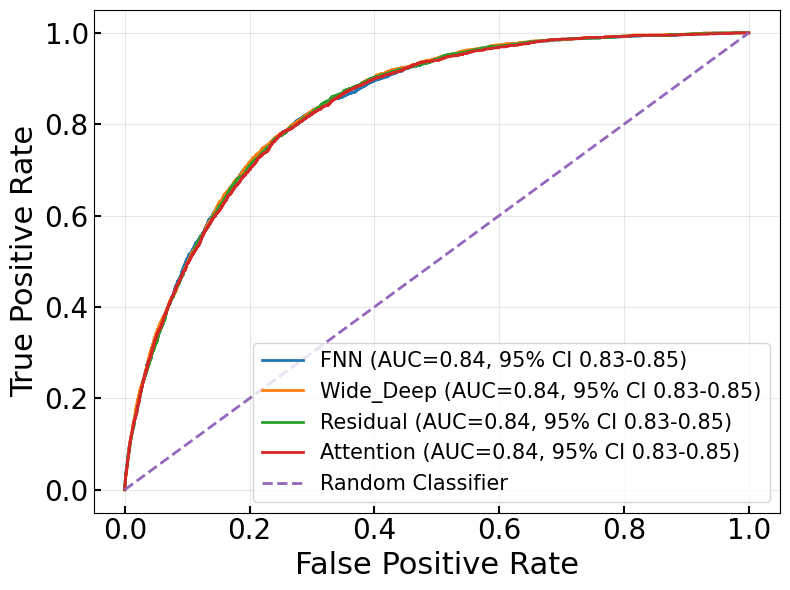


ROC-AUC RESULTS WITH 95% CONFIDENCE INTERVALS


,Model,ROC-AUC,ROC-AUC 95% CI
1,Wide_Deep,0.842059,0.83-0.85
0,FNN,0.840495,0.83-0.85
2,Residual,0.839809,0.83-0.85
3,Attention,0.838387,0.83-0.85


In [15]:


plt.figure(figsize=(8,6))

roc_results = []

for model_name in MODEL_NAMES:

    model = trained_models[model_name]

    y_prob = model.predict(
        X_test,
        verbose=0
    ).ravel()

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    ci_low, ci_high = ci_results_all[
        model_name
    ]["ROC-AUC"]

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC={roc_auc:.2f}, "
            f"95% CI {ci_low:.2f}-{ci_high:.2f})"
        )
    )

    roc_results.append({

        "Model": model_name,

        "ROC-AUC": roc_auc,

        "ROC-AUC 95% CI":
            f"{ci_low:.2f}-{ci_high:.2f}"

    })

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

# ============================================================
# FORMAT FIGURE
# ============================================================

plt.xlabel(
    "False Positive Rate",
    fontsize=22
)

plt.ylabel(
    "True Positive Rate",
    fontsize=22
)


plt.legend(
    fontsize=15,
    loc="lower right"
)
plt.tick_params(
    axis='both',direction='in',length=5,width=1.5,labelsize=20)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "ROC_DPTest.png",
    dpi=150,
    bbox_inches="tight"
)


plt.show()


roc_df = pd.DataFrame(
    roc_results
)

roc_df = roc_df.sort_values(
    "ROC-AUC",
    ascending=False
)

print("\n" + "="*70)
print("ROC-AUC RESULTS WITH 95% CONFIDENCE INTERVALS")
print("="*70)

display(
    roc_df
)

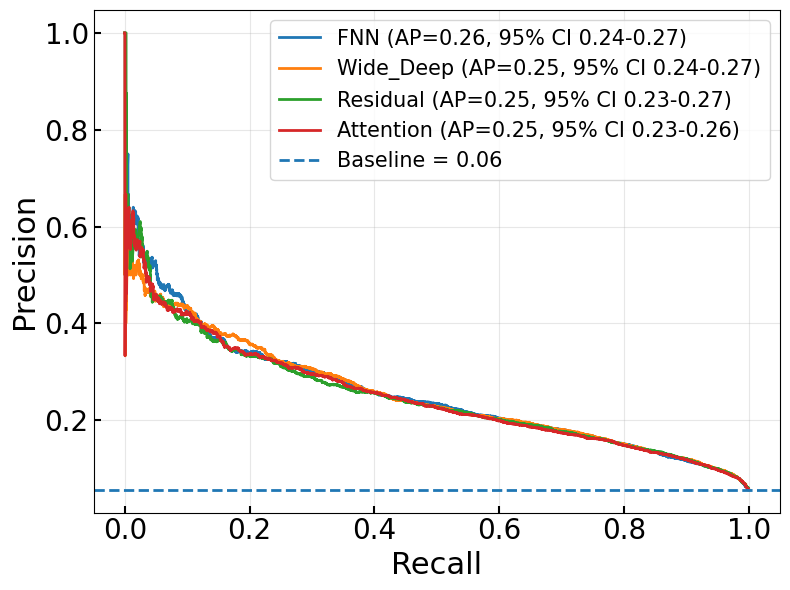


PR-AUC RESULTS WITH 95% CONFIDENCE INTERVALS


,Model,PR-AUC,PR-AUC 95% CI
0,FNN,0.26,0.24-0.27
1,Wide_Deep,0.25,0.24-0.27
2,Residual,0.25,0.23-0.27
3,Attention,0.25,0.23-0.26


In [16]:

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)
plt.figure(figsize=(8,6))

pr_results = []

for model_name in MODEL_NAMES:

    model = trained_models[model_name]

    y_prob = model.predict(
        X_test,
        verbose=0
    ).ravel()

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    # Get bootstrap CI from Cell 7
    ci_low, ci_high = ci_results_all[
        model_name
    ]["PR-AUC"]

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AP={pr_auc:.2f}, "
            f"95% CI {ci_low:.2f}-{ci_high:.2f})"
        )
    )

    pr_results.append({

        "Model": model_name,

        "PR-AUC": round(pr_auc,2),

        "PR-AUC 95% CI":
            f"{ci_low:.2f}-{ci_high:.2f}"

    })

baseline = np.mean(y_test)

plt.axhline(
    baseline,
    linestyle="--",
    linewidth=2,
    label=f"Baseline = {baseline:.2f}"
)

plt.xlabel(
    "Recall",
    fontsize=22
)

plt.ylabel(
    "Precision",
    fontsize=22
)


plt.legend(
    fontsize=15,
    loc="best"
)
plt.tick_params(
    axis='both',direction='in',length=5,width=1.5,labelsize=20)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "PRC_DPTest.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

pr_df = pd.DataFrame(
    pr_results
)

pr_df = pr_df.sort_values(
    "PR-AUC",
    ascending=False
)

print("\n" + "="*70)
print("PR-AUC RESULTS WITH 95% CONFIDENCE INTERVALS")
print("="*70)

display(pr_df)

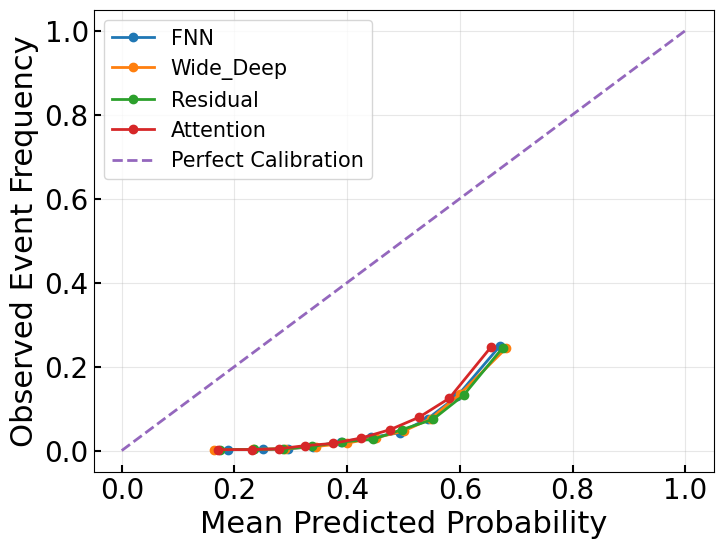


CALIBRATION RESULTS


,Model,Brier Score,Brier Score 95% CI
3,Attention,0.177322,0.18-0.18
0,FNN,0.188595,0.19-0.19
2,Residual,0.190017,0.19-0.19
1,Wide_Deep,0.191001,0.19-0.19


In [18]:

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


plt.figure(figsize=(8,6))

calibration_results = []

for model_name in MODEL_NAMES:

    model = trained_models[model_name]

    y_prob = model.predict(
        X_test,
        verbose=0
    ).ravel()

    prob_true, prob_pred = calibration_curve(
        y_test,
        y_prob,
        n_bins=10,
        strategy="quantile"
    )

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        linewidth=2,
        label=model_name
    )

    brier = brier_score_loss(
        y_test,
        y_prob
    )

    ci_low, ci_high = ci_results_all[
        model_name
    ]["Brier Score"]

    calibration_results.append({

        "Model": model_name,

        "Brier Score": round(brier,42),

        "Brier Score 95% CI":
            f"{ci_low:.2f}-{ci_high:.2f}"

    })
plt.plot([0,1], [0,1],linestyle="--",linewidth=2,label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability",fontsize=22)
plt.ylabel("Observed Event Frequency",fontsize=22)
plt.legend(fontsize=15,loc="best")
plt.tick_params(axis='both',direction='in',length=5,width=1.5,labelsize=20)
plt.grid(alpha=0.3)
plt.savefig("calibrationDP.png",dpi=150,bbox_inches="tight")
plt.show()
calibration_df = pd.DataFrame(calibration_results)
calibration_df = calibration_df.sort_values("Brier Score")
print("\n" + "="*70)
print("CALIBRATION RESULTS")
print("="*70)
display(calibration_df)